In [1]:
import pandas as pd
import numpy as np
import pyxlsb
import matplotlib.pyplot as plt
import os

In [2]:
import pandas as pd
import os

# ============================================================
# 1. Chemins des fichiers
# ============================================================

predictions_file = "../data/output/predictions_525034.csv"
extraction_file = "../data/output/extraction_attributes.csv"

# ============================================================
# 2. Chargement
# ============================================================

df_predictions = pd.read_csv(
    predictions_file,
    encoding="utf-8-sig"
)

df_extraction = pd.read_csv(
    extraction_file,
    encoding="utf-8-sig"
)

# ============================================================
# 3. Vérification
# ============================================================

print("Dataset catégorisation :", df_predictions.shape)
print("Dataset extraction     :", df_extraction.shape)

print("\nColonnes catégorisation :")
print(df_predictions.columns.tolist())

print("\nColonnes extraction :")
print(df_extraction.columns.tolist())

# Aperçu
display(df_predictions.head())
display(df_extraction.head())

Dataset catégorisation : (525034, 5)
Dataset extraction     : (55830, 3)

Colonnes catégorisation :
['Libellé produit', 'Prediction', 'Score', 'Nature', 'Correct']

Colonnes extraction :
['Libellé produit', 'Couleurs', 'Dimensions']


,Libellé produit,Prediction,Score,Nature,Correct
0,table basse carrée detroit design industriel,Table basse,0.497419,Table basse,True
1,ours en peluche géant 150 cm brun,Peluche,0.353465,Peluche,True
2,ours en peluche géant 100 cm blanc,Peluche,0.360220,Peluche,True
3,lot de 4 chaises mia noires pour salle à manger,Chaise,0.447696,Chaise,True
4,meuble tv falko bois blanc et gris,Meuble tv,0.432776,Meuble tv,True


,Libellé produit,Couleurs,Dimensions
0,table basse carrée detroit design industriel,[],[]
1,ours en peluche géant 150 cm brun,['brun'],['150 cm']
2,ours en peluche géant 100 cm blanc,['blanc'],['100 cm']
3,lot de 4 chaises mia noires pour salle à manger,['noir'],[]
4,meuble tv falko bois blanc et gris,"['blanc', 'gris']",[]


In [3]:
# ============================================================
# 4. Préparation de la clé de jointure
# ============================================================

df_predictions["Libellé produit"] = (
    df_predictions["Libellé produit"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df_extraction["Libellé produit"] = (
    df_extraction["Libellé produit"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# ============================================================
# 5. Jointure
# ============================================================

df_enrichi = df_predictions.merge(
    df_extraction,
    on="Libellé produit",
    how="left"
)

# ============================================================
# 6. Vérification
# ============================================================

print("Dimensions avant jointure :", df_predictions.shape)
print("Dimensions extraction    :", df_extraction.shape)
print("Dimensions après jointure:", df_enrichi.shape)

print("\nColonnes du dataset enrichi :")
print(df_enrichi.columns.tolist())

display(df_enrichi.head(10))

Dimensions avant jointure : (525034, 5)
Dimensions extraction    : (55830, 3)
Dimensions après jointure: (525034, 7)

Colonnes du dataset enrichi :
['Libellé produit', 'Prediction', 'Score', 'Nature', 'Correct', 'Couleurs', 'Dimensions']


,Libellé produit,Prediction,Score,Nature,Correct,Couleurs,Dimensions
0,table basse carrée detroit design industriel,Table basse,0.497419,Table basse,True,[],[]
1,ours en peluche géant 150 cm brun,Peluche,0.353465,Peluche,True,['brun'],['150 cm']
2,ours en peluche géant 100 cm blanc,Peluche,0.360220,Peluche,True,['blanc'],['100 cm']
3,lot de 4 chaises mia noires pour salle à manger,Chaise,0.447696,Chaise,True,['noir'],[]
4,meuble tv falko bois blanc et gris,Meuble tv,0.432776,Meuble tv,True,"['blanc', 'gris']",[]
5,meuble tv falko bois blanc et gris,Meuble tv,0.432776,Meuble tv,True,"['blanc', 'gris']",[]
6,meuble à chaussures imitation h tre 3 portes b...,Meuble à chaussures,0.514893,Meuble à chaussures,True,['blanc'],[]
7,meuble à chaussures imitation h tre 3 portes b...,Meuble à chaussures,0.514893,Meuble à chaussures,True,['blanc'],[]
8,meuble à chaussures gris 3 portes blanches ave...,Meuble à chaussures,0.559526,Meuble à chaussures,True,"['blanc', 'gris']",[]
9,meuble à chaussures gris 3 portes blanches ave...,Meuble à chaussures,0.559526,Meuble à chaussures,True,"['blanc', 'gris']",[]


In [4]:
# ============================================================
# 7. Vérification de la jointure
# ============================================================

nb_sans_couleur = df_enrichi["Couleurs"].isna().sum()
nb_sans_dimension = df_enrichi["Dimensions"].isna().sum()

print(f"Lignes totales : {len(df_enrichi):,}")
print(f"Lignes sans couleur : {nb_sans_couleur:,}")
print(f"Lignes sans dimension : {nb_sans_dimension:,}")

print("\nExemples avec extraction :")
display(
    df_enrichi[
        df_enrichi["Couleurs"].notna() |
        df_enrichi["Dimensions"].notna()
    ].head(10)
)

Lignes totales : 525,034
Lignes sans couleur : 0
Lignes sans dimension : 0

Exemples avec extraction :


,Libellé produit,Prediction,Score,Nature,Correct,Couleurs,Dimensions
0,table basse carrée detroit design industriel,Table basse,0.497419,Table basse,True,[],[]
1,ours en peluche géant 150 cm brun,Peluche,0.353465,Peluche,True,['brun'],['150 cm']
2,ours en peluche géant 100 cm blanc,Peluche,0.360220,Peluche,True,['blanc'],['100 cm']
3,lot de 4 chaises mia noires pour salle à manger,Chaise,0.447696,Chaise,True,['noir'],[]
4,meuble tv falko bois blanc et gris,Meuble tv,0.432776,Meuble tv,True,"['blanc', 'gris']",[]
5,meuble tv falko bois blanc et gris,Meuble tv,0.432776,Meuble tv,True,"['blanc', 'gris']",[]
6,meuble à chaussures imitation h tre 3 portes b...,Meuble à chaussures,0.514893,Meuble à chaussures,True,['blanc'],[]
7,meuble à chaussures imitation h tre 3 portes b...,Meuble à chaussures,0.514893,Meuble à chaussures,True,['blanc'],[]
8,meuble à chaussures gris 3 portes blanches ave...,Meuble à chaussures,0.559526,Meuble à chaussures,True,"['blanc', 'gris']",[]
9,meuble à chaussures gris 3 portes blanches ave...,Meuble à chaussures,0.559526,Meuble à chaussures,True,"['blanc', 'gris']",[]


In [5]:
# ============================================================
# 8. Sauvegarde du dataset enrichi
# ============================================================

output_file = "../data/output/dataset_enrichi.csv"

df_enrichi.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(f"Dataset enrichi sauvegardé : {output_file}")
print(f"Nombre de lignes : {len(df_enrichi):,}")
print(f"Nombre de colonnes : {len(df_enrichi.columns)}")

Dataset enrichi sauvegardé : ../data/output/dataset_enrichi.csv
Nombre de lignes : 525,034
Nombre de colonnes : 7


In [6]:
# ============================================================
# 1. VUE GENERALE DU DATASET
# ============================================================

print("===== VUE GENERALE DU DATASET =====\n")

print(f"Nombre de lignes       : {len(df_enrichi):,}")
print(f"Nombre de colonnes     : {len(df_enrichi.columns)}")
print(f"Nombre de produits uniques : {df_enrichi['Libellé produit'].nunique():,}")
print(f"Nombre de Natures      : {df_enrichi['Nature'].nunique():,}")
print(f"Nombre de Predictions  : {df_enrichi['Prediction'].nunique():,}")

print("\nTypes des variables :")
display(df_enrichi.dtypes.to_frame("Type"))

print("\nValeurs manquantes :")
missing = df_enrichi.isna().sum().to_frame("Valeurs manquantes")
missing["Pourcentage"] = (
    missing["Valeurs manquantes"] / len(df_enrichi) * 100
).round(2)

display(missing)

print("\nAperçu :")
display(df_enrichi.head(10))

===== VUE GENERALE DU DATASET =====

Nombre de lignes       : 525,034
Nombre de colonnes     : 7
Nombre de produits uniques : 55,830
Nombre de Natures      : 596
Nombre de Predictions  : 584

Types des variables :


,Type
Libellé produit,str
Prediction,str
Score,float64
Nature,str
Correct,bool
Couleurs,str
Dimensions,str



Valeurs manquantes :


,Valeurs manquantes,Pourcentage
Libellé produit,0,0.00
Prediction,0,0.00
Score,0,0.00
Nature,11745,2.24
Correct,0,0.00
Couleurs,0,0.00
Dimensions,0,0.00



Aperçu :


,Libellé produit,Prediction,Score,Nature,Correct,Couleurs,Dimensions
0,table basse carrée detroit design industriel,Table basse,0.497419,Table basse,True,[],[]
1,ours en peluche géant 150 cm brun,Peluche,0.353465,Peluche,True,['brun'],['150 cm']
2,ours en peluche géant 100 cm blanc,Peluche,0.360220,Peluche,True,['blanc'],['100 cm']
3,lot de 4 chaises mia noires pour salle à manger,Chaise,0.447696,Chaise,True,['noir'],[]
4,meuble tv falko bois blanc et gris,Meuble tv,0.432776,Meuble tv,True,"['blanc', 'gris']",[]
5,meuble tv falko bois blanc et gris,Meuble tv,0.432776,Meuble tv,True,"['blanc', 'gris']",[]
6,meuble à chaussures imitation h tre 3 portes b...,Meuble à chaussures,0.514893,Meuble à chaussures,True,['blanc'],[]
7,meuble à chaussures imitation h tre 3 portes b...,Meuble à chaussures,0.514893,Meuble à chaussures,True,['blanc'],[]
8,meuble à chaussures gris 3 portes blanches ave...,Meuble à chaussures,0.559526,Meuble à chaussures,True,"['blanc', 'gris']",[]
9,meuble à chaussures gris 3 portes blanches ave...,Meuble à chaussures,0.559526,Meuble à chaussures,True,"['blanc', 'gris']",[]


In [7]:
# ============================================================
# 2. TAUX DE CORRECT
# ============================================================

correct_counts = df_enrichi["Correct"].value_counts()

correct_percent = (
    df_enrichi["Correct"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

result_correct = pd.DataFrame({
    "Nombre": correct_counts,
    "Pourcentage": correct_percent
})

display(result_correct)

,Nombre,Pourcentage
Correct,,
False,280495,53.42
True,244539,46.58


In [8]:
# ============================================================
# 3. DISTRIBUTION DES NATURES
# ============================================================

distribution_natures = (
    df_enrichi["Nature"]
    .value_counts()
    .rename_axis("Nature")
    .reset_index(name="Nombre de produits")
)

print(f"Nombre de Natures : {len(distribution_natures)}")

display(distribution_natures.head(20))

Nombre de Natures : 596


,Nature,Nombre de produits
0,Matelas,35593
1,Lit adulte,21133
2,Meuble à chaussures,19105
3,Chaise,15591
4,Bureau,15409
5,Lave linge,14639
6,Bibliotheque,14129
7,Armoire,13316
8,Table basse,12530
9,Meuble tv,12488


In [9]:
# ============================================================
# 4. NATURES ABSENTES DU DATASET DE CONFIANCE
# ============================================================

all_natures = set(df_enrichi["Nature"].dropna().unique())

natures_confiance = set(
    df_enrichi.loc[
        df_enrichi["Correct"] == True,
        "Nature"
    ].dropna().unique()
)

natures_absentes = sorted(
    all_natures - natures_confiance
)

print(f"Nombre total de Natures       : {len(all_natures)}")
print(f"Natures présentes             : {len(natures_confiance)}")
print(f"Natures absentes              : {len(natures_absentes)}")

print("\nNatures absentes :")

for nature in natures_absentes:
    print("-", nature)

Nombre total de Natures       : 596
Natures présentes             : 503
Natures absentes              : 93

Natures absentes :
- ASSIST TEL PAYANTE
- Accessoire allaitem.
- Accessoire aspi
- Accessoire balnéo
- Accessoire biberon
- Accessoire biblio
- Accessoire bureau
- Accessoire ch adulte
- Accessoire ch enfant
- Accessoire cloture
- Accessoire cuisine
- Accessoire de voyage
- Accessoire déguisem
- Accessoire froid
- Accessoire glisse
- Accessoire jeux café
- Accessoire jeux ext
- Accessoire luminaire
- Accessoire pem
- Accessoire plomber
- Accessoire poupée
- Accessoire poussette
- Accessoire sdb
- Accessoire siègeauto
- Accessoire soins
- Accessoire séjour
- Accessoire tapis
- Accessoire textile
- Accessoire vidéoproj
- Appareil convivial
- Archive brun-gris
- Article de ménage
- Autoportée
- Autoradio
- Autre cuisson
- Autre prep culinaire
- Autre soin personne
- Bassin
- Bavoir
- Bûcher
- Carport
- Carte graphique
- Chauffage d'appoint
- Chauffeuse
- Chaussures de sport
- Couver

In [10]:
# ============================================================
# 5. NATURES RARES
# ============================================================

distribution_confiance = (
    df_enrichi[df_enrichi["Correct"] == True]["Nature"]
    .value_counts()
    .rename_axis("Nature")
    .reset_index(name="Nombre d'exemples")
)

print("Nombre de classes avec moins de 5 exemples :",
      (distribution_confiance["Nombre d'exemples"] < 5).sum())

print("Nombre de classes avec moins de 10 exemples :",
      (distribution_confiance["Nombre d'exemples"] < 10).sum())

print("Nombre de classes avec moins de 20 exemples :",
      (distribution_confiance["Nombre d'exemples"] < 20).sum())

print("Nombre de classes avec moins de 50 exemples :",
      (distribution_confiance["Nombre d'exemples"] < 50).sum())

Nombre de classes avec moins de 5 exemples : 96
Nombre de classes avec moins de 10 exemples : 149
Nombre de classes avec moins de 20 exemples : 206
Nombre de classes avec moins de 50 exemples : 272


In [11]:
print("===== CLASSES AVEC MOINS DE 10 EXEMPLES =====")

display(
    distribution_confiance[
        distribution_confiance["Nombre d'exemples"] < 10
    ]
    .sort_values("Nombre d'exemples")
)

===== CLASSES AVEC MOINS DE 10 EXEMPLES =====


,Nature,Nombre d'exemples
478,Pied de lampe,1
475,Alarme de maison,1
476,Composteur,1
477,Sac à langer,1
480,Graveur,1
...,...,...
362,Cireuse,9
360,Porte parapluie,9
359,Biberon,9
358,Plan incliné,9


In [12]:
# ============================================================
# 6. DISTRIBUTION DES SCORES
# ============================================================

print("===== STATISTIQUES DES SCORES =====")

display(
    df_enrichi["Score"].describe()
)

===== STATISTIQUES DES SCORES =====


count    525034.000000
mean          0.494809
std           0.063434
min           0.255221
25%           0.451148
50%           0.491671
75%           0.535352
max           0.755222
Name: Score, dtype: float64

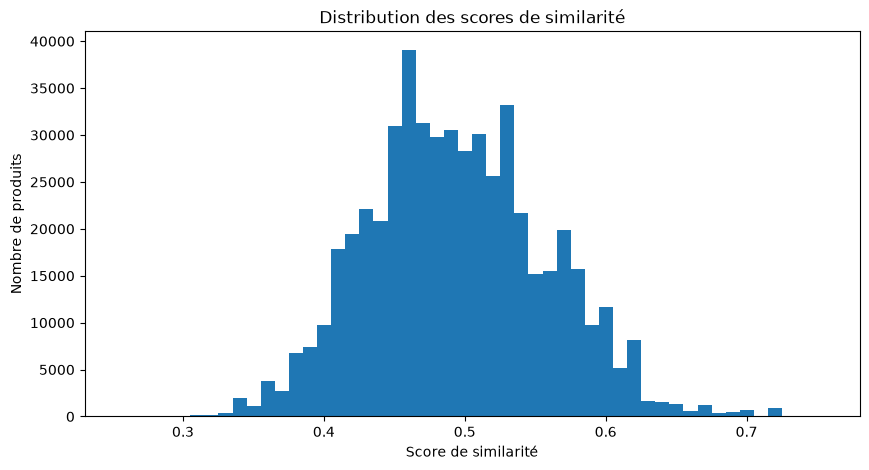

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df_enrichi["Score"].dropna(),
    bins=50
)

plt.xlabel("Score de similarité")
plt.ylabel("Nombre de produits")
plt.title("Distribution des scores de similarité")

plt.show()

In [18]:
# ============================================================
# NETTOYAGE DES RESULTATS D'EXTRACTION
# ============================================================

# Les listes vides [] sont stockées comme chaînes de caractères
# dans le CSV. On les transforme en valeurs manquantes.

for col in ["Couleurs", "Dimensions"]:
    df_enrichi[col] = (
        df_enrichi[col]
        .astype(str)
        .str.strip()
    )

    df_enrichi[col] = df_enrichi[col].replace(
        ["[]", "", "nan", "None"],
        pd.NA
    )

print("Nettoyage terminé.")

Nettoyage terminé.


In [19]:
# ============================================================
# VERIFICATION
# ============================================================

total = len(df_enrichi)

nb_couleurs = df_enrichi["Couleurs"].notna().sum()
nb_dimensions = df_enrichi["Dimensions"].notna().sum()

print("===== ANALYSE DE L'EXTRACTION =====\n")

print(f"Nombre total de lignes       : {total:,}")
print(f"Produits uniques             : {df_enrichi['Libellé produit'].nunique():,}")

print("\nCouleurs :")
print(
    f"  Avec couleur              : {nb_couleurs:,} "
    f"({nb_couleurs / total * 100:.2f}%)"
)
print(
    f"  Sans couleur              : {total - nb_couleurs:,} "
    f"({(total - nb_couleurs) / total * 100:.2f}%)"
)

print("\nDimensions :")
print(
    f"  Avec dimension            : {nb_dimensions:,} "
    f"({nb_dimensions / total * 100:.2f}%)"
)
print(
    f"  Sans dimension            : {total - nb_dimensions:,} "
    f"({(total - nb_dimensions) / total * 100:.2f}%)"
)

===== ANALYSE DE L'EXTRACTION =====

Nombre total de lignes       : 525,034
Produits uniques             : 55,830

Couleurs :
  Avec couleur              : 109,525 (20.86%)
  Sans couleur              : 415,509 (79.14%)

Dimensions :
  Avec dimension            : 225,983 (43.04%)
  Sans dimension            : 299,051 (56.96%)


In [20]:
# ============================================================
# DISTRIBUTION DES COULEURS
# ============================================================

couleurs_series = (
    df_enrichi["Couleurs"]
    .dropna()
    .str.strip("[]")
    .str.replace("'", "", regex=False)
    .str.split(",")
    .explode()
    .str.strip()
)

distribution_couleurs = (
    couleurs_series
    .value_counts()
    .rename_axis("Couleur")
    .reset_index(name="Nombre")
)

display(distribution_couleurs.head(20))

,Couleur,Nombre
0,blanc,41506
1,noir,30673
2,gris,19829
3,marron,4997
4,bleu,3520
5,gris foncé,2866
6,gris clair,2863
7,beige,2795
8,rouge,1992
9,rose,1847


# Classification supervisée des produits e-commerce

## Pipeline

1. Chargement du dataset de confiance enrichi
2. Nettoyage des données
3. Analyse de la distribution des classes
4. Split train/test stratifié
5. Génération des embeddings BGE-M3
6. Entraînement de plusieurs classifieurs
7. Gestion du déséquilibre des classes
8. Évaluation avec plusieurs métriques
9. Sauvegarde des modèles et résultats

> **Important :** le dataset utilisé doit idéalement être le
> `dataset_confiance_enrichi.csv`, après annotation manuelle des classes
> rares ou absentes.

In [5]:
import os
import ast
import json
import joblib
import numpy as np
import pandas as pd
import ollama

from dotenv import load_dotenv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [6]:
load_dotenv()

OLLAMA_HOST = os.getenv(
    "OLLAMA_HOST",
    "http://localhost:11434"
)

OLLAMA_EMBEDDING_MODEL = os.getenv(
    "OLLAMA_EMBEDDING_MODEL",
    "bge-m3"
)

CLASSIFICATION_BATCH_SIZE = int(
    os.getenv(
        "CLASSIFICATION_BATCH_SIZE",
        "32"
    )
)

TEST_SIZE = float(
    os.getenv(
        "CLASSIFICATION_TEST_SIZE",
        "0.20"
    )
)

RANDOM_STATE = int(
    os.getenv(
        "CLASSIFICATION_RANDOM_STATE",
        "42"
    )
)

MIN_CLASS_SAMPLES = int(
    os.getenv(
        "CLASSIFICATION_MIN_CLASS_SAMPLES",
        "15"
    )
)

ollama_client = ollama.Client(
    host=OLLAMA_HOST
)

print("Configuration chargée.")
print(f"Ollama : {OLLAMA_HOST}")
print(f"Modèle d'embedding : {OLLAMA_EMBEDDING_MODEL}")
print(f"Test size : {TEST_SIZE}")
print(f"Random state : {RANDOM_STATE}")
print(f"Minimum d'exemples par classe : {MIN_CLASS_SAMPLES}")

Configuration chargée.
Ollama : http://localhost:11434
Modèle d'embedding : bge-m3
Test size : 0.2
Random state : 42
Minimum d'exemples par classe : 15


In [7]:
BASE_DIR = os.path.abspath("..")

DATA_OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "data",
    "output"
)

DATASET_FILE = os.path.join(
    DATA_OUTPUT_DIR,
    "dataset_confiance.csv"
)

EMBEDDINGS_FILE = os.path.join(
    DATA_OUTPUT_DIR,
    "embeddings_classification.csv"
)

RESULTS_DIR = os.path.join(
    DATA_OUTPUT_DIR,
    "classification_results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

print("BASE_DIR :", BASE_DIR)
print("DATASET_FILE :", DATASET_FILE)
print("RESULTS_DIR :", RESULTS_DIR)

BASE_DIR : c:\Users\anass\Downloads\ecommerce_categorization_v3\ecommerce_categorization_v3
DATASET_FILE : c:\Users\anass\Downloads\ecommerce_categorization_v3\ecommerce_categorization_v3\data\output\dataset_confiance.csv
RESULTS_DIR : c:\Users\anass\Downloads\ecommerce_categorization_v3\ecommerce_categorization_v3\data\output\classification_results


In [8]:
if not os.path.exists(DATASET_FILE):
    raise FileNotFoundError(
        f"""
Dataset introuvable :

{DATASET_FILE}

Le fichier dataset_confiance_enrichi.csv doit être créé
après l'annotation manuelle des classes rares ou absentes.
"""
    )

data = pd.read_csv(
    DATASET_FILE,
    encoding="utf-8-sig"
)

print("=" * 70)
print("CHARGEMENT DU DATASET")
print("=" * 70)

print(f"Nombre de lignes : {len(data):,}")
print(f"Nombre de colonnes : {len(data.columns)}")

print("\nColonnes :")
print(list(data.columns))

display(data.head())

CHARGEMENT DU DATASET
Nombre de lignes : 244,539
Nombre de colonnes : 5

Colonnes :
['Libellé produit', 'Prediction', 'Score', 'Nature', 'Correct']


,Libellé produit,Prediction,Score,Nature,Correct
0,table basse carrée detroit design industriel,Table basse,0.497419,Table basse,True
1,ours en peluche géant 150 cm brun,Peluche,0.353465,Peluche,True
2,ours en peluche géant 100 cm blanc,Peluche,0.360220,Peluche,True
3,lot de 4 chaises mia noires pour salle à manger,Chaise,0.447696,Chaise,True
4,meuble tv falko bois blanc et gris,Meuble tv,0.432776,Meuble tv,True


In [9]:
data = data.copy()

required_columns = [
    "Libellé produit",
    "Nature"
]

missing_columns = [
    col
    for col in required_columns
    if col not in data.columns
]

if missing_columns:
    raise ValueError(
        f"Colonnes manquantes : {missing_columns}"
    )

# --------------------------------------------------------
# Nettoyage du texte
# --------------------------------------------------------

data["Libellé produit"] = (
    data["Libellé produit"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(
        r"[\x00-\x1F\x7F]",
        " ",
        regex=True
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

# --------------------------------------------------------
# Nettoyage de la cible
# --------------------------------------------------------

data["Nature"] = (
    data["Nature"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# --------------------------------------------------------
# Suppression des lignes sans texte ou sans classe
# --------------------------------------------------------

data = data[
    (data["Libellé produit"] != "")
    &
    (data["Nature"] != "")
].copy()

# --------------------------------------------------------
# Suppression des doublons exacts
# --------------------------------------------------------

data = data.drop_duplicates(
    subset=[
        "Libellé produit",
        "Nature"
    ]
).reset_index(drop=True)

print("=" * 70)
print("PRÉTRAITEMENT")
print("=" * 70)

print(
    f"Nombre de lignes après nettoyage : {len(data):,}"
)

print(
    f"Nombre de classes : {data['Nature'].nunique():,}"
)

PRÉTRAITEMENT
Nombre de lignes après nettoyage : 21,258
Nombre de classes : 503


In [10]:
distribution = (
    data["Nature"]
    .value_counts()
    .rename_axis("Nature")
    .reset_index(name="Nombre")
)

distribution["Pourcentage"] = (
    distribution["Nombre"]
    / len(data)
    * 100
)

print("=" * 70)
print("DISTRIBUTION DES CLASSES")
print("=" * 70)

print(
    f"Nombre de classes : {len(distribution)}"
)

print(
    f"Classe la plus représentée : "
    f"{distribution.iloc[0]['Nature']} "
    f"({distribution.iloc[0]['Nombre']:,})"
)

print(
    f"Classe la moins représentée : "
    f"{distribution.iloc[-1]['Nature']} "
    f"({distribution.iloc[-1]['Nombre']:,})"
)

print("\nStatistiques :")

display(
    distribution["Nombre"].describe()
)

DISTRIBUTION DES CLASSES
Nombre de classes : 503
Classe la plus représentée : Meuble tv (1,106)
Classe la moins représentée : Déguisement (1)

Statistiques :


count     503.000000
mean       42.262425
std       112.815060
min         1.000000
25%         3.000000
50%        10.000000
75%        33.000000
max      1106.000000
Name: Nombre, dtype: float64

In [11]:
print("10 classes les plus représentées :")

display(
    distribution.head(10)
)

10 classes les plus représentées :


,Nature,Nombre,Pourcentage
0,Meuble tv,1106,5.202747
1,Table basse,1027,4.831122
2,Chaise,966,4.544172
3,Matelas,753,3.542196
4,Lit adulte,600,2.822467
5,Canapé d'angle,575,2.704864
6,Matelas + sommier,550,2.587261
7,Chaise de bureau,524,2.464954
8,Housse de couette,500,2.352056
9,Tapis de Salon et Ch,500,2.352056


In [12]:
classes_rares = distribution[
    distribution["Nombre"] < 10
].copy()

print(
    f"Nombre de classes avec moins de 10 exemples : "
    f"{len(classes_rares)}"
)

display(classes_rares)

Nombre de classes avec moins de 10 exemples : 243


,Nature,Nombre,Pourcentage
260,Nettoyeur de vitre,9,0.042337
261,Ensemble chambre,9,0.042337
262,Moulin a cafe,9,0.042337
263,Toboggan,9,0.042337
264,Matelas à langer,9,0.042337
...,...,...,...
498,Meule,1,0.004704
499,Store banne,1,0.004704
500,Carte memoire,1,0.004704
501,Acc telephonie,1,0.004704


In [4]:

import pandas as pd
# Chemin vers le CSV final
CSV_PATH = "../data/output/resultats_final_classification_avec_correct.csv"

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")

print(f"Nombre de lignes : {len(df):,}")
print(f"Nombre de colonnes : {len(df.columns)}")

print("\nColonnes :")
print(df.columns.tolist())

display(df.head())

Nombre de lignes : 525,034
Nombre de colonnes : 9

Colonnes :
['Libellé produit', 'Semantic_prediciton', 'Score', 'Nature', 'Semantic_Correct', 'Couleurs', 'Dimensions', 'Classification_Prediction', 'Classification_Correct']


,Libellé produit,Semantic_prediciton,Score,Nature,Semantic_Correct,Couleurs,Dimensions,Classification_Prediction,Classification_Correct
0,table basse carrée detroit design industriel,Table basse,0.497419,Table basse,True,[],[],Table basse,True
1,ours en peluche géant 150 cm brun,Peluche,0.353465,Peluche,True,['brun'],['150 cm'],Peluche,True
2,ours en peluche géant 100 cm blanc,Peluche,0.360220,Peluche,True,['blanc'],['100 cm'],Peluche,True
3,lot de 4 chaises mia noires pour salle à manger,Chaise,0.447696,Chaise,True,['noir'],[],Chaise,True
4,meuble tv falko bois blanc et gris,Meuble tv,0.432776,Meuble tv,True,"['blanc', 'gris']",[],Meuble tv,True


In [5]:
total = len(df)

semantic_correct = df["Semantic_Correct"].sum()
classification_correct = df["Classification_Correct"].sum()

semantic_accuracy = semantic_correct / total
classification_accuracy = classification_correct / total

print("=" * 60)
print("STATISTIQUES GLOBALES")
print("=" * 60)

print(f"Nombre total de lignes              : {total:,}")

print("\n--- Approche sémantique ---")
print(f"Correctes                            : {semantic_correct:,}")
print(f"Incorrectes                          : {total - semantic_correct:,}")
print(f"Accuracy                             : {semantic_accuracy:.2%}")

print("\n--- Classification supervisée ---")
print(f"Correctes                            : {classification_correct:,}")
print(f"Incorrectes                          : {total - classification_correct:,}")
print(f"Accuracy                             : {classification_accuracy:.2%}")

STATISTIQUES GLOBALES
Nombre total de lignes              : 525,034

--- Approche sémantique ---
Correctes                            : 244,539
Incorrectes                          : 280,495
Accuracy                             : 46.58%

--- Classification supervisée ---
Correctes                            : 404,836
Incorrectes                          : 120,198
Accuracy                             : 77.11%


In [6]:
comparison = pd.DataFrame({
    "Approche": [
        "Similarité sémantique",
        "Classification supervisée"
    ],
    "Correctes": [
        semantic_correct,
        classification_correct
    ],
    "Incorrectes": [
        total - semantic_correct,
        total - classification_correct
    ],
    "Accuracy": [
        semantic_accuracy,
        classification_accuracy
    ]
})

comparison

,Approche,Correctes,Incorrectes,Accuracy
0,Similarité sémantique,244539,280495,0.465758
1,Classification supervisée,404836,120198,0.771066


In [8]:
gain_points = (
    classification_accuracy - semantic_accuracy
) * 100

print(
    f"Écart d'accuracy entre les deux approches : "
    f"{gain_points:+.2f} points"
)

Écart d'accuracy entre les deux approches : +30.53 points
